In [2]:
# data manipulation
import numpy as np
import pandas as pd
import datetime as dt
import time
from math import sqrt
from tqdm import tqdm
import holidays

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# feature selection
from sklearn.feature_selection import RFECV

# pipeline
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# models
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# optimization and hyperparameters
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# model evaluation
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report
# interpretowalność modelu
import shap
shap.initjs()

# zapisanie modelu
import joblib



# settings
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [3]:
dataframe = pd.read_excel('default_of_credit_card_clients.xls', header=1)
dataframe

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


This research employed a binary variable, default payment (Yes = 1, No = 0), as the response variable. This study reviewed the literature and used the following 23 variables as explanatory variables:
X1: Amount of the given credit (NT dollar): it includes both the individual consumer credit and his/her family (supplementary) credit.
X2: Gender (1 = male; 2 = female).
X3: Education (1 = graduate school; 2 = university; 3 = high school; 4 = others).
X4: Marital status (1 = married; 2 = single; 3 = others).
X5: Age (year).
X6 - X11: History of past payment. We tracked the past monthly payment records (from April to September, 2005) as follows: X6 = the repayment status in September, 2005; X7 = the repayment status in August, 2005; . . .;X11 = the repayment status in April, 2005. The measurement scale for the repayment status is: -1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above.
X12-X17: Amount of bill statement (NT dollar). X12 = amount of bill statement in September, 2005; X13 = amount of bill statement in August, 2005; . . .; X17 = amount of bill statement in April, 2005.
X18-X23: Amount of previous payment (NT dollar). X18 = amount paid in September, 2005; X19 = amount paid in August, 2005; . . .;X23 = amount paid in April, 2005.

Zrozumienie uwarunkowań biznesowych:

Jeżeli zadaniem jest określenie czy przyznać kartę, moim zdaniem nie ma tutaj danych do określenia tego faktu. Zaleganie z wypłatą za poprzedni miesiąc nie może być targetem do nauki modelu. To, że ktoś zalega z wypłatą nie oznacza, że bankowi nie opłaca się wydać karty kredytowej.

W takim wypadku celem projektu jest stworzenie modelu przewidującego ryzyko niewywiązania się klienta ze zobowiązania w kolejnym miesiącu. Wynik modelu może wspierać decyzję banku dotyczącą przyznania lub przedłużenia limitu kredytowego obecnemu klientowi.

Zbiór zawiera historię płatności obecnych klientów, dlatego model nie jest przeznaczony do oceny nowych klientów bez historii kredytowej.

In [4]:
dataframe['ID'].is_monotonic_increasing

True

In [5]:
# Podstawowe informacje o danych
print(f'Liczba obserwacji: {dataframe.shape[0]}')
print(f'Liczba kolumn: {dataframe.shape[1]}')

display(dataframe.head())
display(dataframe.info())
display(dataframe.describe().T)

Liczba obserwacji: 30000
Liczba kolumn: 25


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

None

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


Nietypowa numeracja PAY_0 a potem PAY_2 ale zapewne PAY_0 jest poprzednim miesiącem czyli równie dobrze mogłaby się nazywać PAY_1.

In [6]:
# Braki danych
missing_values = (
    dataframe.isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_values[missing_values > 0]

Series([], dtype: float64)

In [7]:
# Kontrola identyfikatorów
print('Liczba unikalnych ID:', dataframe['ID'].nunique())
print('Liczba duplikatów ID:', dataframe['ID'].duplicated().sum())
print('ID uporządkowane rosnąco:', dataframe['ID'].is_monotonic_increasing)

all_ids = pd.RangeIndex(
    start=dataframe['ID'].min(),
    stop=dataframe['ID'].max() + 1,
)

missing_ids = all_ids.difference(dataframe['ID'])
print('Brakujące ID:', list(missing_ids))

Liczba unikalnych ID: 30000
Liczba duplikatów ID: 0
ID uporządkowane rosnąco: True
Brakujące ID: []


In [8]:
categorical_columns = [
    'LIMIT_BAL',
    'AGE',
    'SEX',
    'EDUCATION',
    'MARRIAGE',
    'PAY_0',
    'PAY_2',
    'PAY_3',
    'PAY_4',
    'PAY_5',
    'PAY_6',
    'default payment next month'
]

for column in categorical_columns:
    print(f'\n{column}')
    print(dataframe[column].value_counts().sort_index())


LIMIT_BAL
LIMIT_BAL
10000       493
16000         2
20000      1976
30000      1610
40000       230
           ... 
750000        4
760000        1
780000        2
800000        2
1000000       1
Name: count, Length: 81, dtype: int64

AGE
AGE
21      67
22     560
23     931
24    1127
25    1186
26    1256
27    1477
28    1409
29    1605
30    1395
31    1217
32    1158
33    1146
34    1162
35    1113
36    1108
37    1041
38     944
39     954
40     870
41     824
42     794
43     670
44     700
45     617
46     570
47     501
48     466
49     452
50     411
51     340
52     304
53     325
54     247
55     209
56     178
57     122
58     122
59      83
60      67
61      56
62      44
63      31
64      31
65      24
66      25
67      16
68       5
69      15
70      10
71       3
72       3
73       4
74       1
75       3
79       1
Name: count, dtype: int64

SEX
SEX
1    11888
2    18112
Name: count, dtype: int64

EDUCATION
EDUCATION
0       14
1    10585
2    14030
3  

In [9]:
dataframe['EDUCATION'] = dataframe['EDUCATION'].replace(
    [0, 5, 6],
    4,
)

In [10]:
dataframe['MARRIAGE'] = dataframe['MARRIAGE'].replace(
    0,
    3,
)

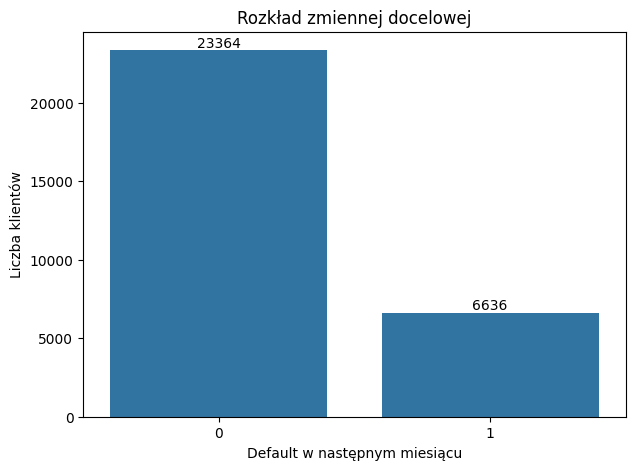

In [11]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=dataframe,
    x='default payment next month',
)

ax.bar_label(ax.containers[0])

plt.title('Rozkład zmiennej docelowej')
plt.xlabel('Default w następnym miesiącu')
plt.ylabel('Liczba klientów')
plt.show()

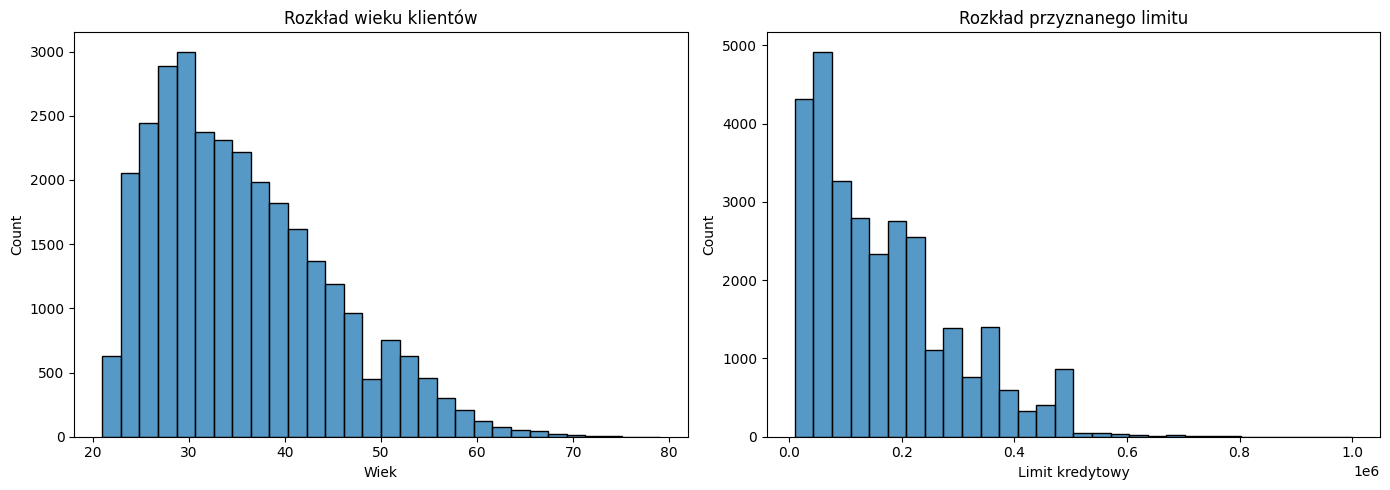

In [12]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5),
)

sns.histplot(
    data=dataframe,
    x='AGE',
    bins=30,
    ax=axes[0],
)

axes[0].set_title('Rozkład wieku klientów')
axes[0].set_xlabel('Wiek')

sns.histplot(
    data=dataframe,
    x='LIMIT_BAL',
    bins=30,
    ax=axes[1],
)

axes[1].set_title('Rozkład przyznanego limitu')
axes[1].set_xlabel('Limit kredytowy')

plt.tight_layout()
plt.show()

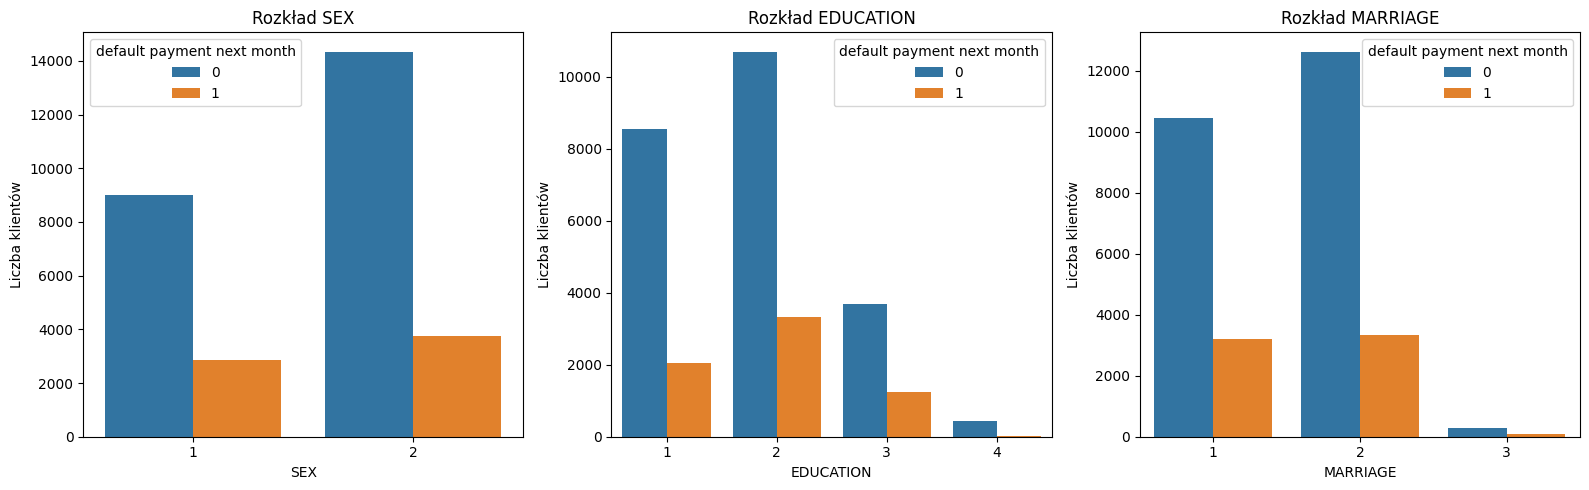

In [13]:
categorical_columns = [
    'SEX',
    'EDUCATION',
    'MARRIAGE',
]

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(16, 5),
)

for column, ax in zip(categorical_columns, axes):
    sns.countplot(
        data=dataframe,
        x=column,
        hue='default payment next month',
        ax=ax,
    )

    ax.set_title(f'Rozkład {column}')
    ax.set_ylabel('Liczba klientów')

plt.tight_layout()
plt.show()

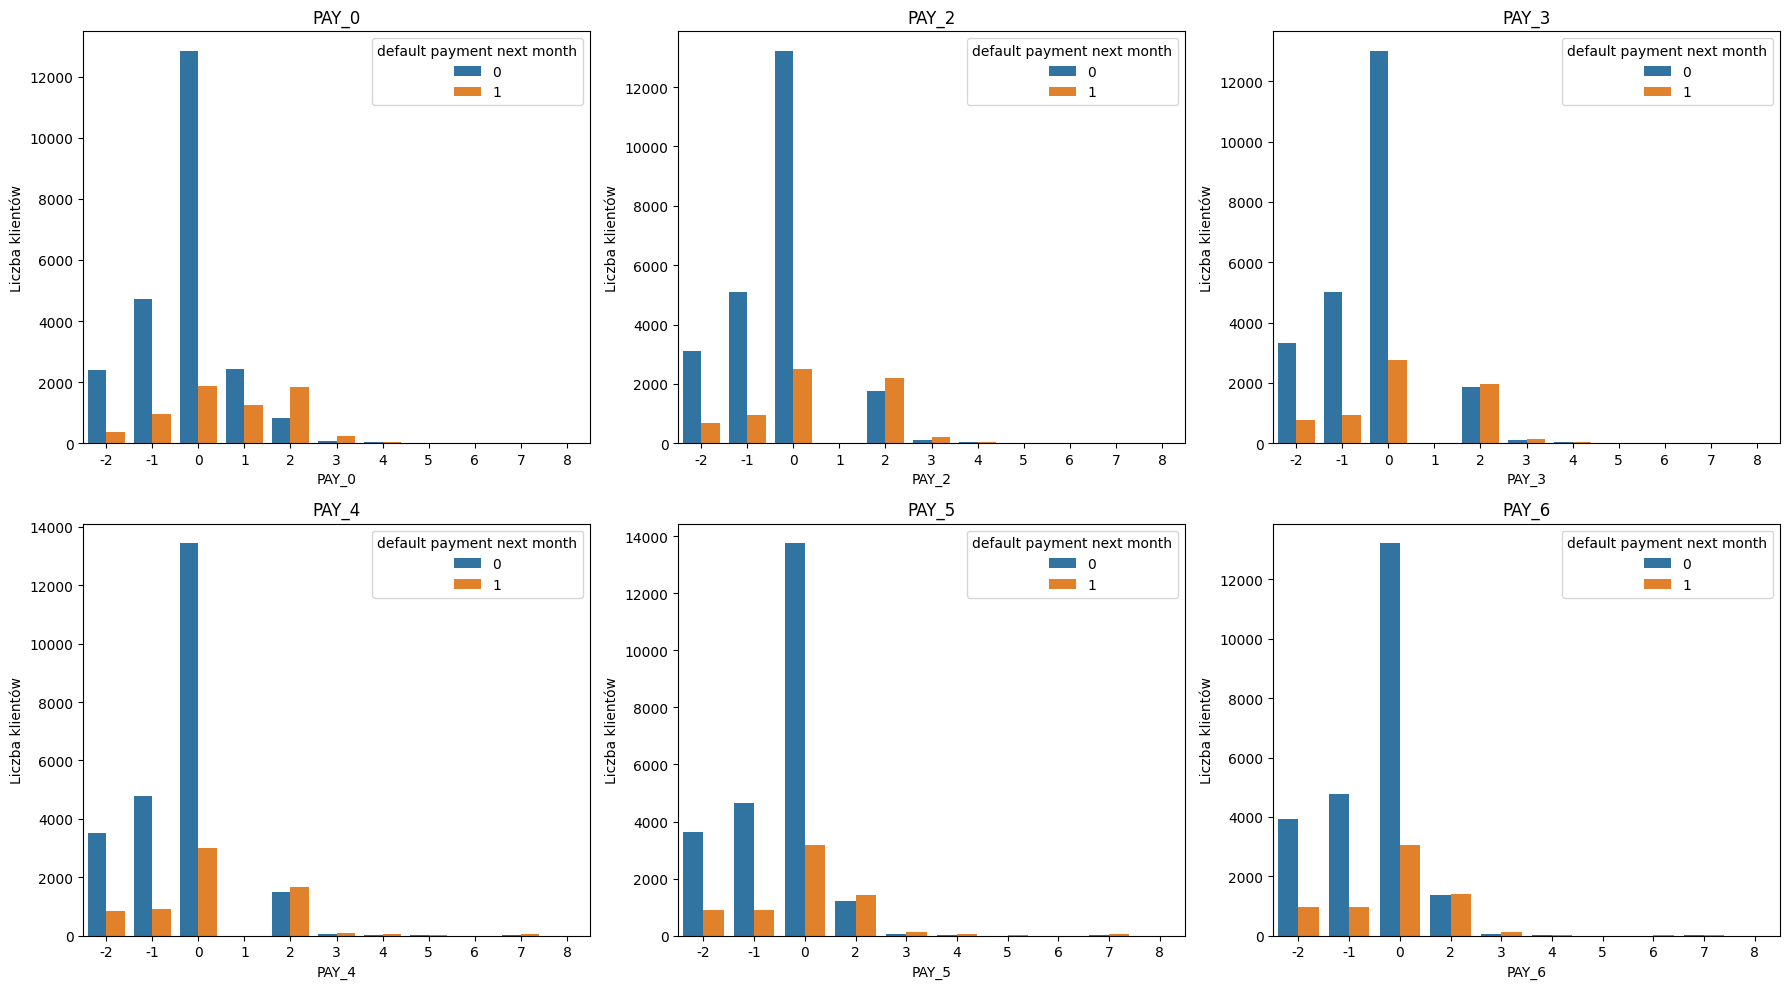

In [14]:
payment_status_columns = [
    'PAY_0',
    'PAY_2',
    'PAY_3',
    'PAY_4',
    'PAY_5',
    'PAY_6',
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(18, 10),
)

for column, ax in zip(payment_status_columns, axes.flatten()):
    sns.countplot(
        data=dataframe,
        x=column,
        hue='default payment next month',
        ax=ax,
    )

    ax.set_title(column)
    ax.set_ylabel('Liczba klientów')

plt.tight_layout()
plt.show()

Zrozumienie danych:
W kolumnach EDUCATION oraz MARRIAGE znaleziono wartości niewystępujące w opisie danych. Wartości 0, 5 i 6 w kolumnie EDUCATION przypisano do kategorii 4 oznaczającej inne wykształcenie. Wartość 0 w kolumnie MARRIAGE przypisano do kategorii 3 oznaczającej inny stan cywilny. Pozostałe wartości uznano za prawidłowe.

In [15]:
X = dataframe.drop(columns=['ID','default payment next month',])
y = dataframe['default payment next month']

print('X:', X.shape)
print('y:', y.shape)

display(X.head())
display(y.head())

X: (30000, 23)
y: (30000,)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


0    1
1    1
2    0
3    0
4    0
Name: default payment next month, dtype: int64

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

Model bazowy:

In [17]:
dummy_model = DummyClassifier(strategy='most_frequent')

dummy_model.fit(X_train, y_train)

y_pred_dummy = dummy_model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred_dummy))
print('Precision:', precision_score(y_test, y_pred_dummy))
print('Recall:', recall_score(y_test, y_pred_dummy))
print('F1:', f1_score(y_test, y_pred_dummy))

print(classification_report(y_test, y_pred_dummy))

Accuracy: 0.7788333333333334
Precision: 0.0
Recall: 0.0
F1: 0.0
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      4673
           1       0.00      0.00      0.00      1327

    accuracy                           0.78      6000
   macro avg       0.39      0.50      0.44      6000
weighted avg       0.61      0.78      0.68      6000



In [18]:
tree_model = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced',
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
y_pred_tree_proba = tree_model.predict_proba(X_test)[:, 1]

print('Accuracy:', accuracy_score(y_test, y_pred_tree))
print('Precision:', precision_score(y_test, y_pred_tree))
print('Recall:', recall_score(y_test, y_pred_tree))
print('F1:', f1_score(y_test, y_pred_tree))
print('ROC AUC:', roc_auc_score(y_test, y_pred_tree_proba))

print(classification_report(y_test, y_pred_tree))

Accuracy: 0.7288333333333333
Precision: 0.38789237668161436
Recall: 0.3911077618688772
F1: 0.38949343339587245
ROC AUC: 0.6077246978788019
              precision    recall  f1-score   support

           0       0.83      0.82      0.83      4673
           1       0.39      0.39      0.39      1327

    accuracy                           0.73      6000
   macro avg       0.61      0.61      0.61      6000
weighted avg       0.73      0.73      0.73      6000



In [19]:
forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1,
)

forest_model.fit(X_train, y_train)

y_pred_forest = forest_model.predict(X_test)
y_pred_forest_proba = forest_model.predict_proba(X_test)[:, 1]

print('Accuracy:', accuracy_score(y_test, y_pred_forest))
print('Precision:', precision_score(y_test, y_pred_forest))
print('Recall:', recall_score(y_test, y_pred_forest))
print('F1:', f1_score(y_test, y_pred_forest))
print('ROC AUC:', roc_auc_score(y_test, y_pred_forest_proba))

print(classification_report(y_test, y_pred_forest))

Accuracy: 0.7995
Precision: 0.5528109028960818
Recall: 0.48907309721175585
F1: 0.5189924030387845
ROC AUC: 0.7605566844824064
              precision    recall  f1-score   support

           0       0.86      0.89      0.87      4673
           1       0.55      0.49      0.52      1327

    accuracy                           0.80      6000
   macro avg       0.71      0.69      0.70      6000
weighted avg       0.79      0.80      0.79      6000



In [20]:
models_results = pd.DataFrame({
    'model': [
        'dummy_model',
        'tree_model',
        'forest_model',
    ],
    'accuracy': [
        accuracy_score(y_test, y_pred_dummy),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_forest),
    ],
    'precision': [
        precision_score(y_test, y_pred_dummy),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_forest),
    ],
    'recall': [
        recall_score(y_test, y_pred_dummy),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_forest),
    ],
    'f1': [
        f1_score(y_test, y_pred_dummy),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_forest),
    ],
    'roc_auc': [
        np.nan,
        roc_auc_score(y_test, y_pred_tree_proba),
        roc_auc_score(y_test, y_pred_forest_proba),
    ],
})

models_results

,model,accuracy,precision,recall,f1,roc_auc
0,dummy_model,0.778833,0.000000,0.000000,0.000000,NaN
1,tree_model,0.728833,0.387892,0.391108,0.389493,0.607725
2,forest_model,0.799500,0.552811,0.489073,0.518992,0.760557


Random Forest jest najlepszym modelem bazowym, więc jego będziemy stroić.

In [21]:
parameters = {
    'n_estimators': [200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 5],
}

forest_grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        class_weight='balanced',
        n_jobs=-1,
    ),
    parameters,
    scoring='f1',
    cv=5,
    n_jobs=-1,
)

forest_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 5], 'min_samples_split': [2, 10], 'n_estimators': [200, 300]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose:

In [22]:
print(forest_grid.best_params_)
print(forest_grid.best_score_)

{'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 200}
0.5448661801781512


In [23]:
best_forest_model = forest_grid.best_estimator_

y_pred_best_forest = best_forest_model.predict(X_test)
y_pred_best_forest_proba = best_forest_model.predict_proba(X_test)[:, 1]

print('Accuracy:', accuracy_score(y_test, y_pred_best_forest))
print('Precision:', precision_score(y_test, y_pred_best_forest))
print('Recall:', recall_score(y_test, y_pred_best_forest))
print('F1:', f1_score(y_test, y_pred_best_forest))
print('ROC AUC:', roc_auc_score(y_test, y_pred_best_forest_proba))

print(classification_report(y_test, y_pred_best_forest))

Accuracy: 0.7768333333333334
Precision: 0.49622166246851385
Recall: 0.5938206480783723
F1: 0.5406518010291596
ROC AUC: 0.7753909768167466
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      4673
           1       0.50      0.59      0.54      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.79      0.78      0.78      6000



Po optymalizacji hiperparametrów najlepszy model Random Forest uzyskał średni wynik F1 równy około 0.545 w walidacji krzyżowej. Następnie model został sprawdzony na zbiorze testowym, który nie był wykorzystywany podczas strojenia hiperparametrów.

In [24]:
y_pred_best_forest_proba = best_forest_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_best_forest_proba >= threshold).astype(int)

    threshold_results.append({
        'threshold': threshold,
        'accuracy': accuracy_score(y_test, y_pred_threshold),
        'precision': precision_score(y_test, y_pred_threshold),
        'recall': recall_score(y_test, y_pred_threshold),
        'f1': f1_score(y_test, y_pred_threshold),
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,threshold,accuracy,precision,recall,f1
0,0.10,0.221167,0.221167,1.000000,0.362222
1,0.15,0.235500,0.224103,0.997739,0.365999
2,0.20,0.290000,0.235528,0.984175,0.380093
3,0.25,0.402667,0.263268,0.945742,0.411881
4,0.30,0.506667,0.294694,0.883195,0.441931
5,0.35,0.595000,0.331294,0.816127,0.471279
6,0.40,0.684833,0.384710,0.709118,0.498807
7,0.45,0.745167,0.447396,0.647325,0.529104
8,0.50,0.776833,0.496222,0.593821,0.540652
9,0.55,0.794500,0.534918,0.542577,0.538721


Danie innego progu klasyfikacji nic nie daje, w sumie nie powinno to być dziwne skoro modele uczyły się dla progu 0,5

In [25]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler


mlp_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation='relu',
        solver='adam',
        max_iter=300,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.2,
    ))
])

mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_test)
y_pred_mlp_proba = mlp_model.predict_proba(X_test)[:, 1]

print('Accuracy:', accuracy_score(y_test, y_pred_mlp))
print('Precision:', precision_score(y_test, y_pred_mlp))
print('Recall:', recall_score(y_test, y_pred_mlp))
print('F1:', f1_score(y_test, y_pred_mlp))
print('ROC AUC:', roc_auc_score(y_test, y_pred_mlp_proba))

print(classification_report(y_test, y_pred_mlp))

Accuracy: 0.8173333333333334
Precision: 0.6567164179104478
Recall: 0.36473247927656366
F1: 0.4689922480620155
ROC AUC: 0.7650473603672656
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000



In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Sequential()

model.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

model.summary()




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                768       
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dense_2 (Dense)             (None, 1)                 17        
                                                                 
Total params: 1313 (5.13 KB)
Trainable params: 1313 (5.13 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [27]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
)

Epoch 1/100


600/600 [==============================] - 2s 2ms/step - loss: 0.4968 - accuracy: 0.7889 - val_loss: 0.4719 - val_accuracy: 0.8052
Epoch 2/100
600/600 [==============================] - 1s 2ms/step - loss: 0.4451 - accuracy: 0.8185 - val_loss: 0.4598 - val_accuracy: 0.8129
Epoch 3/100
600/600 [==============================] - 1s 1ms/step - loss: 0.4359 - accuracy: 0.8214 - val_loss: 0.4550 - val_accuracy: 0.8123
Epoch 4/100
600/600 [==============================] - 1s 2ms/step - loss: 0.4314 - accuracy: 0.8221 - val_loss: 0.4523 - val_accuracy: 0.8131
Epoch 5/100
600/600 [==============================] - 1s 1ms/step - loss: 0.4289 - accuracy: 0.8231 - val_loss: 0.4540 - val_accuracy: 0.8100
Epoch 6/100
600/600 [==============================] - 1s 2ms/step - loss: 0.4262 - accuracy: 0.8232 - val_loss: 0.4494 - val_accuracy: 0.8092
Epoch 7/100
600/600 [==============================] - 1s 2ms/step - loss: 0.4245 - accuracy: 0.8242 - val_loss: 0.4486 - val_accuracy: 0.81

In [28]:
y_pred_mlp_proba = model.predict(X_test_scaled).flatten()
y_pred_mlp = (y_pred_mlp_proba >= 0.5).astype(int)

print('Accuracy:', accuracy_score(y_test, y_pred_mlp))
print('Precision:', precision_score(y_test, y_pred_mlp))
print('Recall:', recall_score(y_test, y_pred_mlp))
print('F1:', f1_score(y_test, y_pred_mlp))
print('ROC AUC:', roc_auc_score(y_test, y_pred_mlp_proba))

print(classification_report(y_test, y_pred_mlp))

188/188 [==============================] - 0s 2ms/step
Accuracy: 0.818
Precision: 0.6594301221166893
Recall: 0.36623963828183875
F1: 0.47093023255813954
ROC AUC: 0.7658499636595033
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.37      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000



Proste modele sieci nie uzyskały lepszych wyników

In [30]:
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

model_2 = Sequential()

model_2.add(Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model_2.add(BatchNormalization())
model_2.add(Dropout(0.5))

model_2.add(Dense(64, activation='relu'))
model_2.add(BatchNormalization())
model_2.add(Dropout(0.4))

model_2.add(Dense(32, activation='relu'))
model_2.add(Dropout(0.3))

model_2.add(Dense(16, activation='relu'))

model_2.add(Dense(1, activation='sigmoid'))

model_2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

model_2.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 128)               3072      
                                                                 
 batch_normalization (Batch  (None, 128)               512       
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_5 (Dense)             (None, 64)                8256      
                                                                 
 batch_normalization_1 (Bat  (None, 64)                256       
 chNormalization)                                                
                                                                 
 dropout_1 (Dropout)         (None, 64)               

In [31]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
)

history_model_2 = model_2.fit(
    X_train_scaled,
    y_train,
    epochs=150,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping],
)

Epoch 1/150
300/300 [==============================] - 2s 4ms/step - loss: 0.5169 - accuracy: 0.7865 - val_loss: 0.4616 - val_accuracy: 0.8048
Epoch 2/150
300/300 [==============================] - 1s 3ms/step - loss: 0.4699 - accuracy: 0.8030 - val_loss: 0.4555 - val_accuracy: 0.8081
Epoch 3/150
300/300 [==============================] - 1s 3ms/step - loss: 0.4630 - accuracy: 0.8078 - val_loss: 0.4581 - val_accuracy: 0.8096
Epoch 4/150
300/300 [==============================] - 1s 3ms/step - loss: 0.4532 - accuracy: 0.8091 - val_loss: 0.4577 - val_accuracy: 0.8100
Epoch 5/150
300/300 [==============================] - 1s 3ms/step - loss: 0.4513 - accuracy: 0.8096 - val_loss: 0.4569 - val_accuracy: 0.8104
Epoch 6/150
300/300 [==============================] - 1s 3ms/step - loss: 0.4473 - accuracy: 0.8107 - val_loss: 0.4525 - val_accuracy: 0.8102
Epoch 7/150
300/300 [==============================] - 1s 3ms/step - loss: 0.4463 - accuracy: 0.8136 - val_loss: 0.4520 - val_accuracy: 0.8110

In [32]:
y_pred_mlp_2_proba = model_2.predict(X_test_scaled).flatten()
y_pred_mlp_2 = (y_pred_mlp_2_proba >= 0.5).astype(int)

print('Accuracy:', accuracy_score(y_test, y_pred_mlp_2))
print('Precision:', precision_score(y_test, y_pred_mlp_2))
print('Recall:', recall_score(y_test, y_pred_mlp_2))
print('F1:', f1_score(y_test, y_pred_mlp_2))
print('ROC AUC:', roc_auc_score(y_test, y_pred_mlp_2_proba))

print(classification_report(y_test, y_pred_mlp_2))

188/188 [==============================] - 0s 1ms/step
Accuracy: 0.8163333333333334
Precision: 0.6642335766423357
Recall: 0.34287867370007535
F1: 0.452286282306163
ROC AUC: 0.7714082776991265
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.34      0.45      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.67      6000
weighted avg       0.80      0.82      0.79      6000



In [33]:

models_results = pd.DataFrame({
    'model': [
        'dummy_model',
        'tree_model',
        'forest_model',
        'best_forest_model',
        'mlp_model',
        'mlp_model_2',
    ],
    'accuracy': [
        accuracy_score(y_test, y_pred_dummy),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_forest),
        accuracy_score(y_test, y_pred_best_forest),
        accuracy_score(y_test, y_pred_mlp),
        accuracy_score(y_test, y_pred_mlp_2),
    ],
    'precision': [
        precision_score(y_test, y_pred_dummy),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_forest),
        precision_score(y_test, y_pred_best_forest),
        precision_score(y_test, y_pred_mlp),
        precision_score(y_test, y_pred_mlp_2),
    ],
    'recall': [
        recall_score(y_test, y_pred_dummy),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_forest),
        recall_score(y_test, y_pred_best_forest),
        recall_score(y_test, y_pred_mlp),
        recall_score(y_test, y_pred_mlp_2),
    ],
    'f1': [
        f1_score(y_test, y_pred_dummy),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_forest),
        f1_score(y_test, y_pred_best_forest),
        f1_score(y_test, y_pred_mlp),
        f1_score(y_test, y_pred_mlp_2),
    ],
    'roc_auc': [
        np.nan,
        roc_auc_score(y_test, y_pred_tree_proba),
        roc_auc_score(y_test, y_pred_forest_proba),
        roc_auc_score(y_test, y_pred_best_forest_proba),
        roc_auc_score(y_test, y_pred_mlp_proba),
        roc_auc_score(y_test, y_pred_mlp_2_proba),
    ],
})

models_results.sort_values(by='f1', ascending=False)

,model,accuracy,precision,recall,f1,roc_auc
3,best_forest_model,0.776833,0.496222,0.593821,0.540652,0.775391
2,forest_model,0.799500,0.552811,0.489073,0.518992,0.760557
4,mlp_model,0.818000,0.659430,0.366240,0.470930,0.765850
5,mlp_model_2,0.816333,0.664234,0.342879,0.452286,0.771408
1,tree_model,0.728833,0.387892,0.391108,0.389493,0.607725
0,dummy_model,0.778833,0.000000,0.000000,0.000000,NaN


W tym projekcie accuracy nie powinna być główną metryką wyboru modelu. Ważniejsze są recall dla klasy default oraz F1-score, ponieważ lepiej opisują zdolność modelu do wykrywania klientów ryzykownych.

In [44]:
from tensorflow.keras.metrics import Precision, Recall
model_3 = Sequential()

model_3.add(Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model_3.add(BatchNormalization())
model_3.add(Dropout(0.5))

model_3.add(Dense(64, activation='relu'))
model_3.add(BatchNormalization())
model_3.add(Dropout(0.4))

model_3.add(Dense(64, activation='relu'))
model_3.add(BatchNormalization())
model_3.add(Dropout(0.4))

model_3.add(Dense(32, activation='relu'))
model_3.add(Dropout(0.3))

model_3.add(Dense(16, activation='relu'))

model_3.add(Dense(1, activation='sigmoid'))

model_3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
    ],
)

model_3.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_24 (Dense)            (None, 128)               3072      
                                                                 
 batch_normalization_8 (Bat  (None, 128)               512       
 chNormalization)                                                
                                                                 
 dropout_12 (Dropout)        (None, 128)               0         
                                                                 
 dense_25 (Dense)            (None, 64)                8256      
                                                                 
 batch_normalization_9 (Bat  (None, 64)                256       
 chNormalization)                                                
                                                                 
 dropout_13 (Dropout)        (None, 64)               

In [45]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
)

In [46]:
class_weight = {
    0: 1,
    1: 5,
}

In [47]:
history_model_3 = model_3.fit(
    X_train_scaled,
    y_train,
    epochs=150,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping],
    class_weight=class_weight,
)

Epoch 1/150
300/300 [==============================] - 3s 4ms/step - loss: 1.2493 - accuracy: 0.4859 - precision: 0.2608 - recall: 0.7380 - val_loss: 0.5814 - val_accuracy: 0.7956 - val_precision: 0.5682 - val_recall: 0.5004
Epoch 2/150
300/300 [==============================] - 1s 3ms/step - loss: 1.1361 - accuracy: 0.6050 - precision: 0.3208 - recall: 0.7237 - val_loss: 0.5762 - val_accuracy: 0.7783 - val_precision: 0.5205 - val_recall: 0.5803
Epoch 3/150
300/300 [==============================] - 1s 3ms/step - loss: 1.1172 - accuracy: 0.6245 - precision: 0.3328 - recall: 0.7153 - val_loss: 0.5971 - val_accuracy: 0.7713 - val_precision: 0.5064 - val_recall: 0.6045
Epoch 4/150
300/300 [==============================] - 1s 4ms/step - loss: 1.1009 - accuracy: 0.6452 - precision: 0.3457 - recall: 0.6993 - val_loss: 0.5946 - val_accuracy: 0.7513 - val_precision: 0.4731 - val_recall: 0.6224
Epoch 5/150
300/300 [==============================] - 1s 3ms/step - loss: 1.0866 - accuracy: 0.6474

In [48]:
y_pred_mlp_3_proba = model_3.predict(X_test_scaled).flatten()
y_pred_mlp_3 = (y_pred_mlp_3_proba >= 0.5).astype(int)

print('Accuracy:', accuracy_score(y_test, y_pred_mlp_3))
print('Precision:', precision_score(y_test, y_pred_mlp_3))
print('Recall:', recall_score(y_test, y_pred_mlp_3))
print('F1:', f1_score(y_test, y_pred_mlp_3))
print('ROC AUC:', roc_auc_score(y_test, y_pred_mlp_3_proba))

print(classification_report(y_test, y_pred_mlp_3))

188/188 [==============================] - 0s 1ms/step
Accuracy: 0.7668333333333334
Precision: 0.4770700636942675
Recall: 0.5644310474755087
F1: 0.5170866413531239
ROC AUC: 0.7582454708227014
              precision    recall  f1-score   support

           0       0.87      0.82      0.85      4673
           1       0.48      0.56      0.52      1327

    accuracy                           0.77      6000
   macro avg       0.67      0.69      0.68      6000
weighted avg       0.78      0.77      0.77      6000



Po zwiększeniu wagi ryzykownych klientów
większy recall = mniej przepuszczonych ryzykownych klientów
mniejszy precision = więcej bezpiecznych klientów błędnie oznaczonych jako ryzykowni

In [49]:
confusion_matrix(y_test, y_pred_mlp_3)


array([[3852,  821],
       [ 578,  749]], dtype=int64)

In [50]:
confusion_matrix(y_test, y_pred_best_forest)

array([[3873,  800],
       [ 539,  788]], dtype=int64)

Nie tutaj na sieci korzyści .Las po strojeniu wygrywa i pod metrykami, i pod macierzą pomyłek.

Warto zauważyć, że zmienna docelowa upraszcza problem biznesowy do klasyfikacji binarnej: default lub brak defaultu w następnym miesiącu. W praktyce klienci oznaczeni jako default mogą mieć różny poziom ryzyka. Część z nich może mieć niewielkie lub krótkotrwałe opóźnienia, a część może charakteryzować się poważniejszym problemem ze spłatą.

Z tego powodu model binarny może być traktowany jako pierwszy etap oceny ryzyka. W dalszym rozwoju projektu można byłoby rozważyć model wieloklasowy lub scoring ryzyka, który dzieli klientów na kilka poziomów ryzyka, np. niski, średni i wysoki.

In [51]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stacking_model = StackingClassifier(
    estimators=[
        ('decision_tree', DecisionTreeClassifier(
            random_state=42,
            class_weight='balanced',
        )),
        ('random_forest', RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight='balanced',
            n_jobs=-1,
        )),
        ('best_random_forest', RandomForestClassifier(
            max_depth=10,
            min_samples_leaf=5,
            min_samples_split=2,
            n_estimators=200,
            random_state=42,
            class_weight='balanced',
            n_jobs=-1,
        )),
        ('logistic_regression', Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(
                max_iter=1000,
                class_weight='balanced',
                random_state=42,
            ))
        ])),
    ],
    final_estimator=LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42,
    ),
    stack_method='predict_proba',
    cv=5,
    n_jobs=-1,
)

In [52]:
stacking_parameters = {
    'passthrough': [False, True],
    'final_estimator__C': [0.1, 1, 10],
}
stacking_grid = GridSearchCV(
    stacking_model,
    stacking_parameters,
    scoring='f1',
    cv=5,
    n_jobs=-1,
)

stacking_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",StackingClass...redict_proba')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'final_estimator__C': [0.1, 1, ...], 'passthrough': [False, True]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of infor

In [53]:
best_stacking_model = stacking_grid.best_estimator_

y_pred_best_stacking = best_stacking_model.predict(X_test)
y_pred_best_stacking_proba = best_stacking_model.predict_proba(X_test)[:, 1]

print('Accuracy:', accuracy_score(y_test, y_pred_best_stacking))
print('Precision:', precision_score(y_test, y_pred_best_stacking))
print('Recall:', recall_score(y_test, y_pred_best_stacking))
print('F1:', f1_score(y_test, y_pred_best_stacking))
print('ROC AUC:', roc_auc_score(y_test, y_pred_best_stacking_proba))

print(classification_report(y_test, y_pred_best_stacking))

Accuracy: 0.7608333333333334
Precision: 0.4687861271676301
Recall: 0.6111529766390355
F1: 0.5305855413804383
ROC AUC: 0.7745179824581916
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      4673
           1       0.47      0.61      0.53      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.71      0.69      6000
weighted avg       0.79      0.76      0.77      6000



In [54]:
confusion_matrix(y_test, y_pred_best_stacking)

array([[3754,  919],
       [ 516,  811]], dtype=int64)

Model stackingowy osiągnął najwyższy recall dla klasy default, co oznacza, że wykrywał największą liczbę klientów ryzykownych. Jednocześnie miał niższą precision niż najlepszy Random Forest, czyli częściej oznaczał klientów bez defaultu jako ryzykownych.

Z perspektywy ograniczania ryzyka kredytowego stacking może być interesujący, ponieważ przepuszcza mniej klientów z rzeczywistym defaultem. Jeśli jednak istotne jest zachowanie równowagi pomiędzy wykrywaniem defaultu a liczbą fałszywych alarmów, najlepszym kompromisem pozostaje best_forest_model.